In [42]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
import torchvision.models as models
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


#### Explore the dataset. 

In [34]:
DATA_ROOT = "/info/etu/m2/s2405959/deepLearning/L3_project/Tiger-Fox-Elephant"

def explore_dataset(data_root):
    animals = ['elephant', 'tiger', 'fox']
    stats = {}
    for animal in animals:
        pos_dir = os.path.join(data_root, animal)
        neg_dir = os.path.join(data_root, f"{animal.capitalize()}_negative_class")
        pos_images = [f for f in os.listdir(pos_dir) if f.endswith(('.jpg'))]
        neg_images = [f for f in os.listdir(neg_dir) if f.endswith(('.jpg'))]
        stats[animal] = {'positive': len(pos_images), 'negative': len(neg_images), 'total': len(pos_images) + len(neg_images)}
        print(f"{animal.upper()}: {len(pos_images)} positive, {len(neg_images)} negative")
    return stats

explore_dataset(DATA_ROOT)

ELEPHANT: 100 positive, 100 negative
TIGER: 100 positive, 100 negative
FOX: 100 positive, 100 negative


{'elephant': {'positive': 100, 'negative': 100, 'total': 200},
 'tiger': {'positive': 100, 'negative': 100, 'total': 200},
 'fox': {'positive': 100, 'negative': 100, 'total': 200}}

### View some Samples

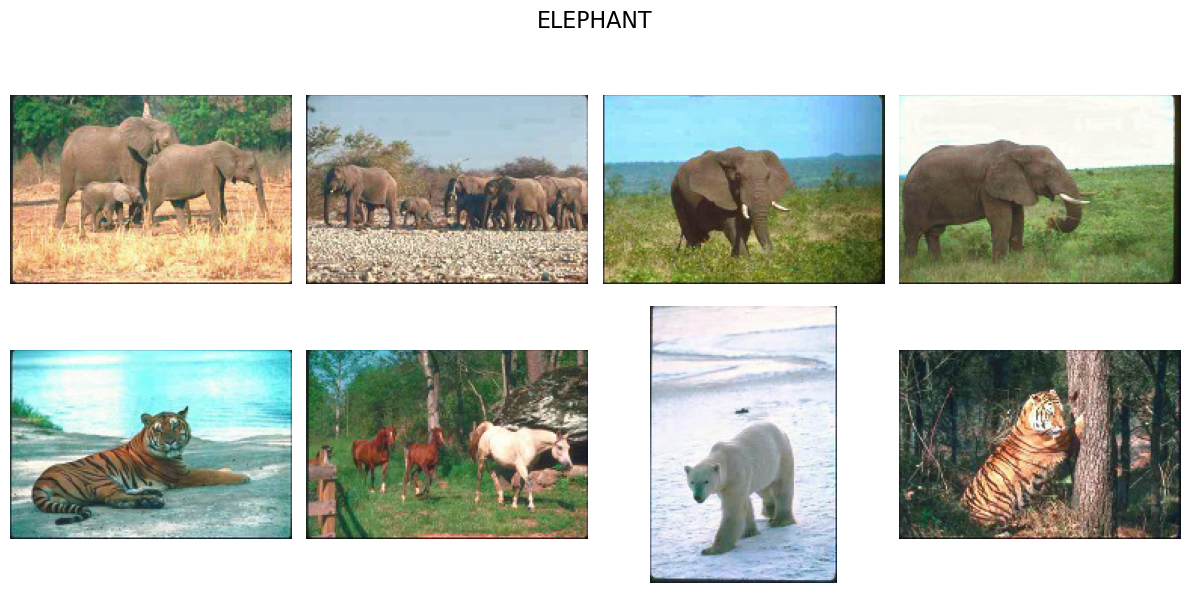

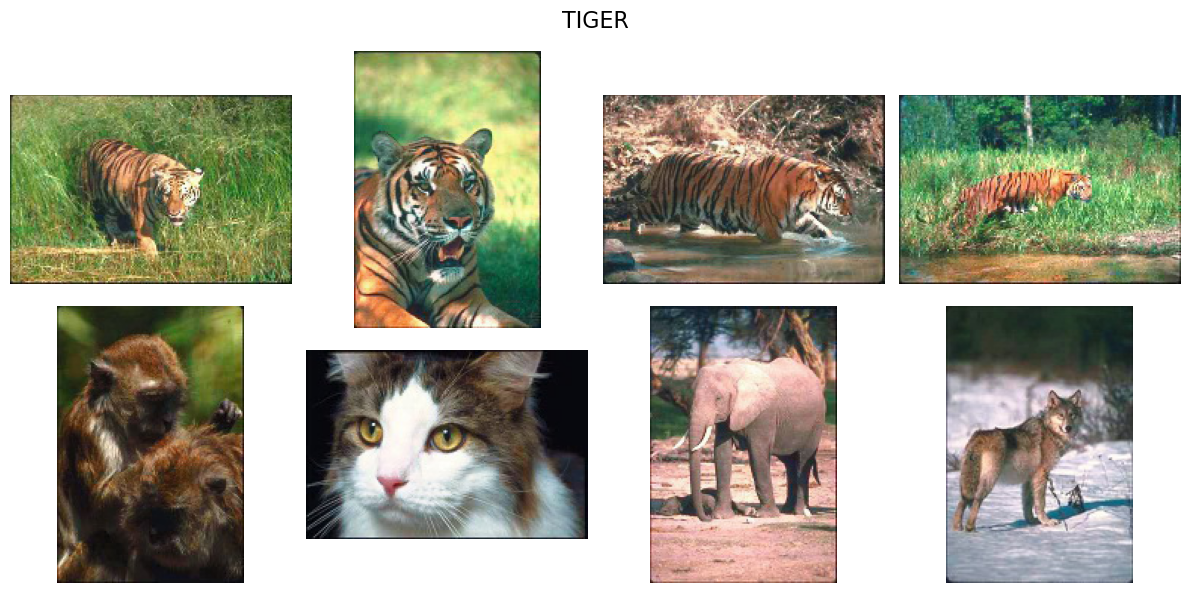

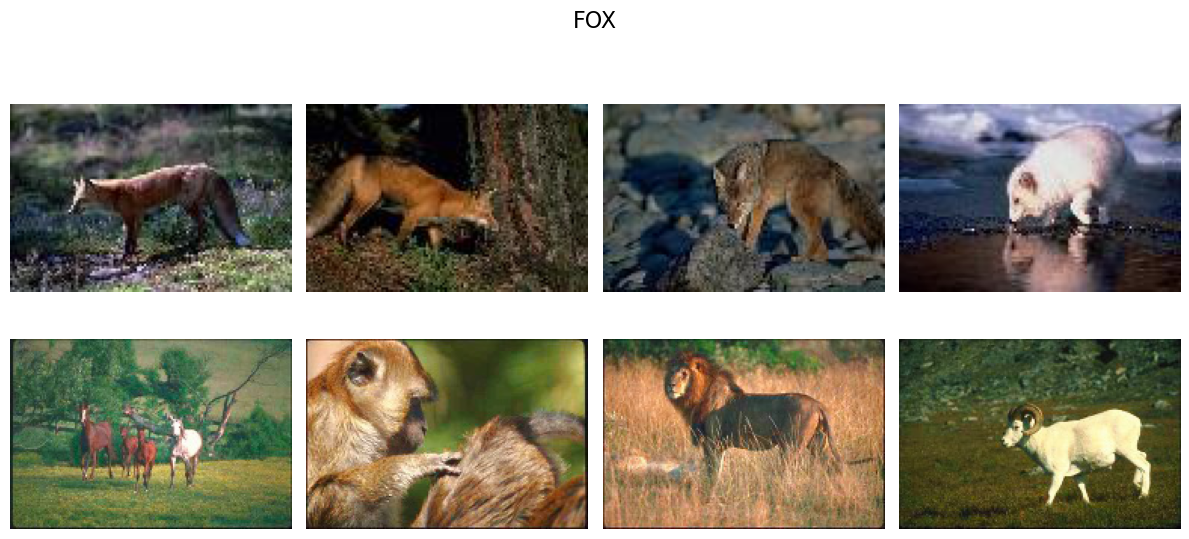

In [40]:
animals = ['elephant', 'tiger', 'fox']
for animal in animals:
    pos_dir = os.path.join(DATA_ROOT, animal)
    neg_dir = os.path.join(DATA_ROOT, f"{animal.capitalize()}_negative_class")
    pos_imgs = [os.path.join(pos_dir, f) for f in os.listdir(pos_dir) if f.endswith('.jpg')][:4]
    neg_imgs = [os.path.join(neg_dir, f) for f in os.listdir(neg_dir) if f.endswith('.jpg')][:4]
    
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    fig.suptitle(f'{animal.upper()}', fontsize=16)
    
    for i, img_path in enumerate(pos_imgs):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
    
    for i, img_path in enumerate(neg_imgs):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[1, i].imshow(img)
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

#### Class for loading dataset. 

In [35]:
class AnimalBinaryDataset(Dataset):
    # define instroctor
    def __init__(self, data_root, animal, img_size=(128,128)):
        self.img_size = img_size
        self.image_paths = []
        self.labels = []

        # load the positive class images (original)
        pos_dir = os.path.join(data_root, animal)
        pos_images = [os.path.join(pos_dir, i) for i in os.listdir(pos_dir) if i.endswith('.jpg')]
        self.image_paths.extend(pos_images)
        self.labels.extend([1] * len(pos_images))

        # load the positive class images (generated)
        pos_gen_dir = os.path.join(data_root, f"{animal}_generated")
        if os.path.exists(pos_gen_dir):
            pos_gen_images = [os.path.join(pos_gen_dir, i) for i in os.listdir(pos_gen_dir) if i.endswith('.jpg')]
            self.image_paths.extend(pos_gen_images)
            self.labels.extend([1] * len(pos_gen_images))

        # load the negative class
        neg_dir = os.path.join(data_root, f"{animal.capitalize()}_negative_class")
        neg_images = [os.path.join(neg_dir, i) for i in os.listdir(neg_dir) if i.endswith('.jpg')]
        self.image_paths.extend(neg_images)
        self.labels.extend([0] * len(neg_images))

    # length of the dataset
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # read the image, output (height, width, 3)
        image = cv2.imread(self.image_paths[idx])
        # Converts the image from BGR (OpenCV format) to RGB (PyTorch expects RGB).
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.img_size)
        # convert pixels to float32 for pytorch and normalize the values
        image = image.astype(np.float32) / 255.0
        # Converts the NumPy array into a PyTorch tensor.
        # changes the dimension order: From (H, W, C) → (C, H, W) pytorch expects channels to be first
        image = torch.from_numpy(image).permute(2, 0, 1)
        # take the label and convert it to float32 PyTorch tensor
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label

#### Implement the model. 

In [36]:
class CNN_model(nn.Module):
    def __init__(self, img_size=128):
        super(CNN_model, self).__init__()
        # 3 in, 16 out, same H and W
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        # INCREASED dropout to reduce overfitting
        self.dropout1 = nn.Dropout2d(0.4)
        # reduce the H and W to (128-(k-2))/(s=2) = 64, output shape = (16,64,64)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

        # calculate the number of neurons after the conv and pooling
        self.flatten_size = 16 * (img_size // 2) * (img_size // 2)
        # REDUCED neurons to 64 (was 128) to reduce model capacity
        self.fc1 = nn.Linear(self.flatten_size, 64)
        # INCREASED dropout to reduce overfitting
        self.dropout2 = nn.Dropout(0.6)
        # in 64 to 1 out
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.dropout1(x)
        x = self.maxpool(x)
        x = x.view(x.size(0), -1)  # flatten neurons in 1D
        x = torch.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x


  # Using ReLU in hidden layers allows the network to learn complex, 
        # non-linear patterns efficiently by keeping gradients from vanishing 
        # and enabling faster, more stable training.

#### Second version of the model with transfer learning 

In [46]:
import torchvision.models as models

class CNN_model_ResNet50(nn.Module):
    def __init__(self):
        super(CNN_model_ResNet50, self).__init__()
        self.resnet = models.resnet50(pretrained=True)
        # not to compute gradients for these parameters during backpropagation (freezing)
        for param in self.resnet.parameters():
            param.requires_grad = False
        num_features = self.resnet.fc.in_features # Retrieve number of neurons from the last layer of ResNet50. 
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.resnet(x)

In [49]:
def train(model, train_loader, val_loader, epochs, animal, checkpoint_dir='checkpoints'):
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    # Print class distribution
    train_dataset = train_loader.dataset.dataset  # Get original dataset from Subset
    pos_count = sum(train_dataset.labels)
    neg_count = len(train_dataset.labels) - pos_count
    print(f"Training with: {int(pos_count)} positive, {int(neg_count)} negative images")
    
    # WEIGHTED LOSS: pos_weight=1/3 because we have 3x more positive (300) than negative (100)
    pos_weight = torch.tensor([1/3]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    # REDUCED LR and INCREASED weight_decay to reduce overfitting
    optimizer = optim.AdamW(model.parameters(), lr=0.00001, weight_decay=0.1)
    # Scale LR into half if 10 epochs the metric doesn't improve
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    train_losses = []
    val_losses = []
    patience_counter = 0
    early_stop_patience = 15
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        # loop over images by batch
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).unsqueeze(1)  # reshape labels to [batch,1] from [batch]
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                # change the shape of label tensor from [batch] to [batch,1]
                images, labels = images.to(device), labels.to(device).unsqueeze(1)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
        #  the average loss over all batches in the epoch
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        accuracy = 100 * correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        if (epoch + 1) % 10 == 0:  # Print loss only each 10 epochs
            print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Accuracy: {accuracy:.2f}%")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"Early stop at epoch {epoch+1}")
                break 

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'accuracy': accuracy
    }

    torch.save(checkpoint, os.path.join(checkpoint_dir, f'{animal}_exp.pth'))

    return train_losses, val_losses








In [38]:
def plot_losses(train_losses, val_losses, animal_name):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{animal_name.capitalize()} - Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


 Training ELEPHANT Binary Classification
Training with: 300 positive, 100 negative images
Epoch [10/50] Train Loss: 0.1444 | Val Loss: 0.1095 | Accuracy: 95.00%
Epoch [20/50] Train Loss: 0.0703 | Val Loss: 0.0904 | Accuracy: 93.75%
Epoch [30/50] Train Loss: 0.0382 | Val Loss: 0.0822 | Accuracy: 96.25%
Early stop at epoch 38


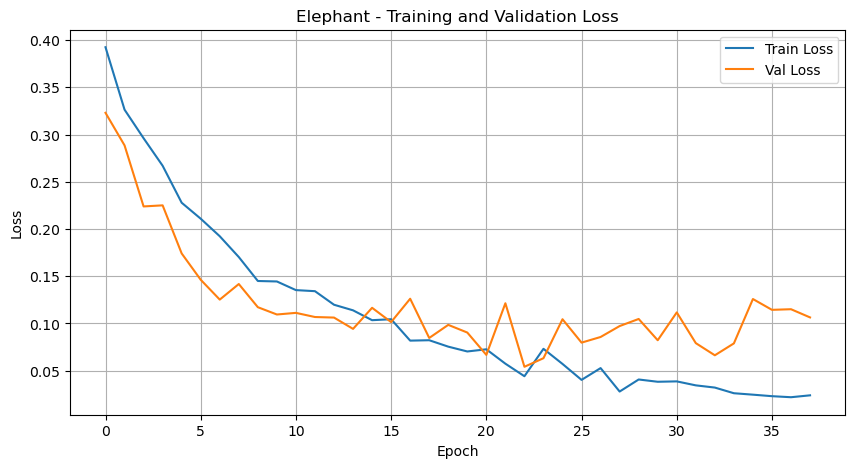


 Training TIGER Binary Classification
Training with: 300 positive, 100 negative images
Epoch [10/50] Train Loss: 0.2096 | Val Loss: 0.2806 | Accuracy: 80.00%
Epoch [20/50] Train Loss: 0.1019 | Val Loss: 0.3512 | Accuracy: 81.25%
Epoch [30/50] Train Loss: 0.0798 | Val Loss: 0.3213 | Accuracy: 82.50%
Early stop at epoch 33


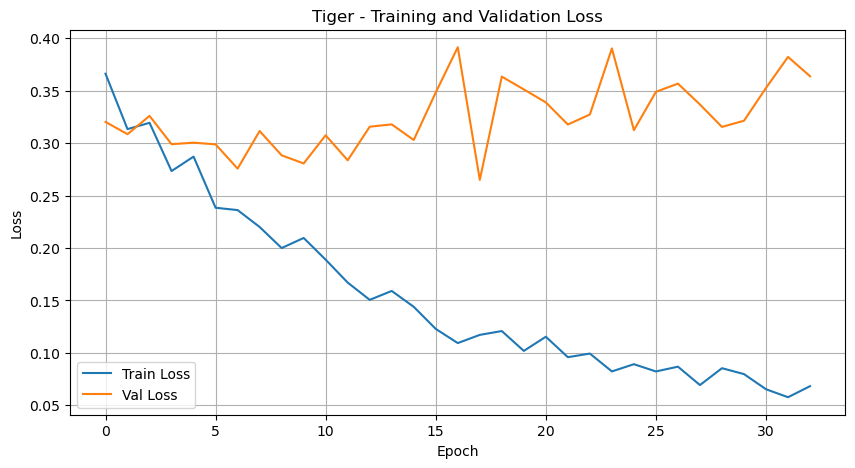


 Training FOX Binary Classification
Training with: 300 positive, 100 negative images
Epoch [10/50] Train Loss: 0.2489 | Val Loss: 0.2062 | Accuracy: 88.75%
Epoch [20/50] Train Loss: 0.0851 | Val Loss: 0.1025 | Accuracy: 92.50%
Epoch [30/50] Train Loss: 0.0597 | Val Loss: 0.0646 | Accuracy: 96.25%
Epoch [40/50] Train Loss: 0.0293 | Val Loss: 0.0772 | Accuracy: 96.25%
Epoch [50/50] Train Loss: 0.0384 | Val Loss: 0.0811 | Accuracy: 96.25%


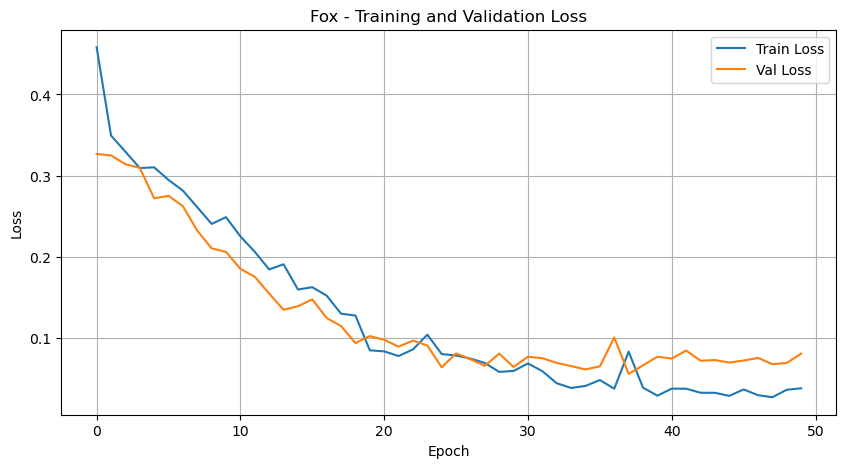

In [39]:
BATCH_SIZE = 8
EPOCHS = 50
IMG_SIZE = 128

animals = ['elephant', 'tiger', 'fox']
results = {}

for animal in animals:
    print(f"\n Training {animal.upper()} Binary Classification")

    train_dataset = AnimalBinaryDataset(DATA_ROOT,animal, img_size=(IMG_SIZE,IMG_SIZE))
    val_dataset = AnimalBinaryDataset(DATA_ROOT,animal, img_size=(IMG_SIZE,IMG_SIZE))

    train_idx, val_idx = train_test_split(range(len(train_dataset)), test_size=0.2, random_state=42, stratify=train_dataset.labels)

    train_subset = torch.utils.data.Subset(train_dataset, train_idx)
    val_subset =  torch.utils.data.Subset(val_dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=True)

    model = CNN_model(img_size=IMG_SIZE).to(device)
    train_losses, val_losses = train(model, train_loader, val_loader, EPOCHS, animal)

    results[animal] = {'train_losses': train_losses,'val_losses': val_losses}

    plot_losses(train_losses, val_losses, animal)

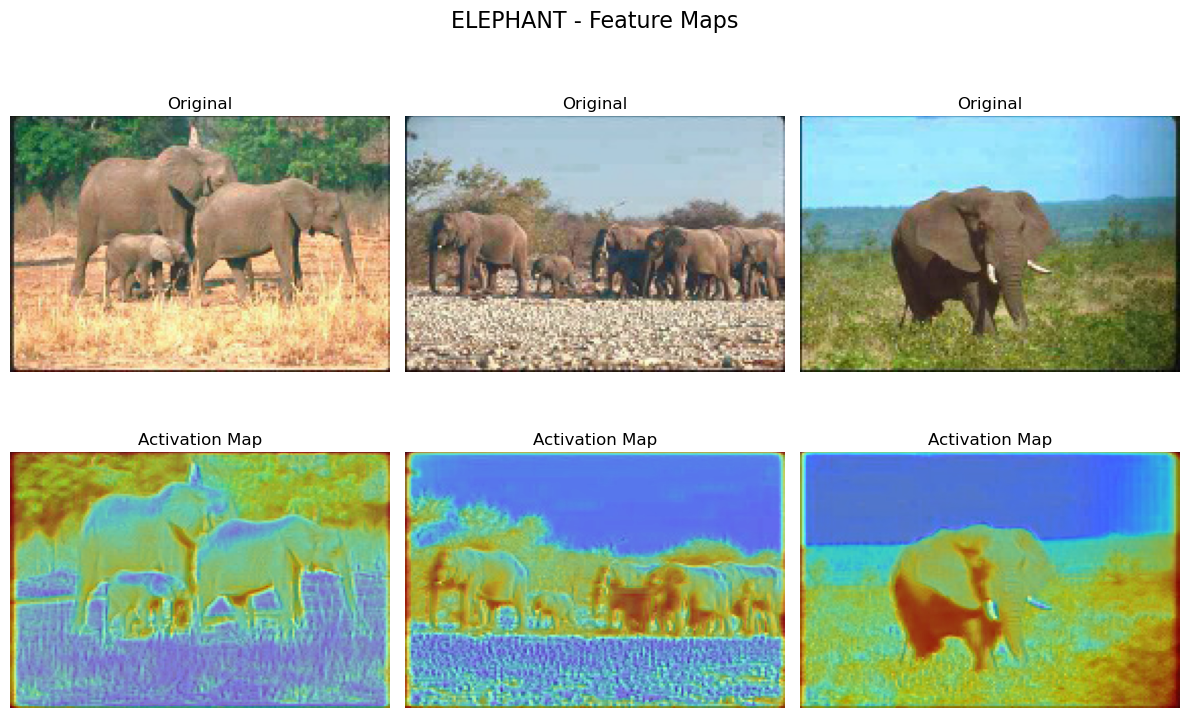

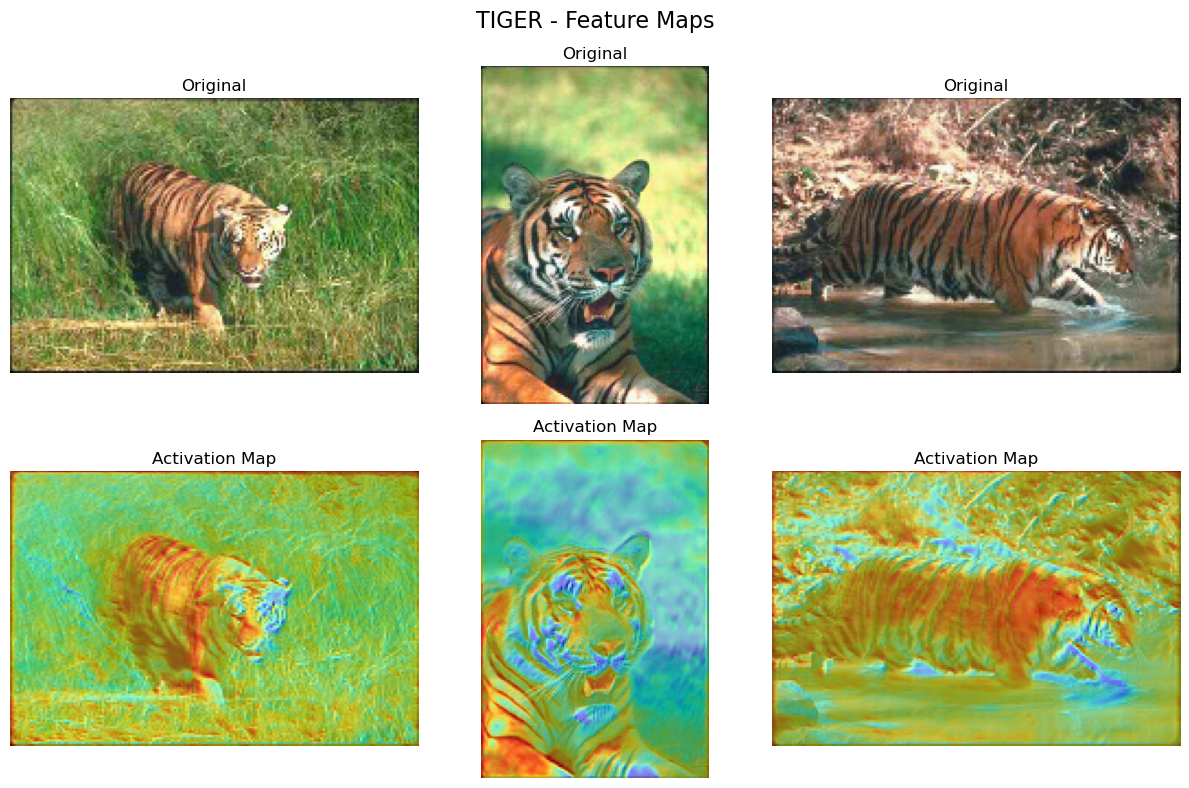

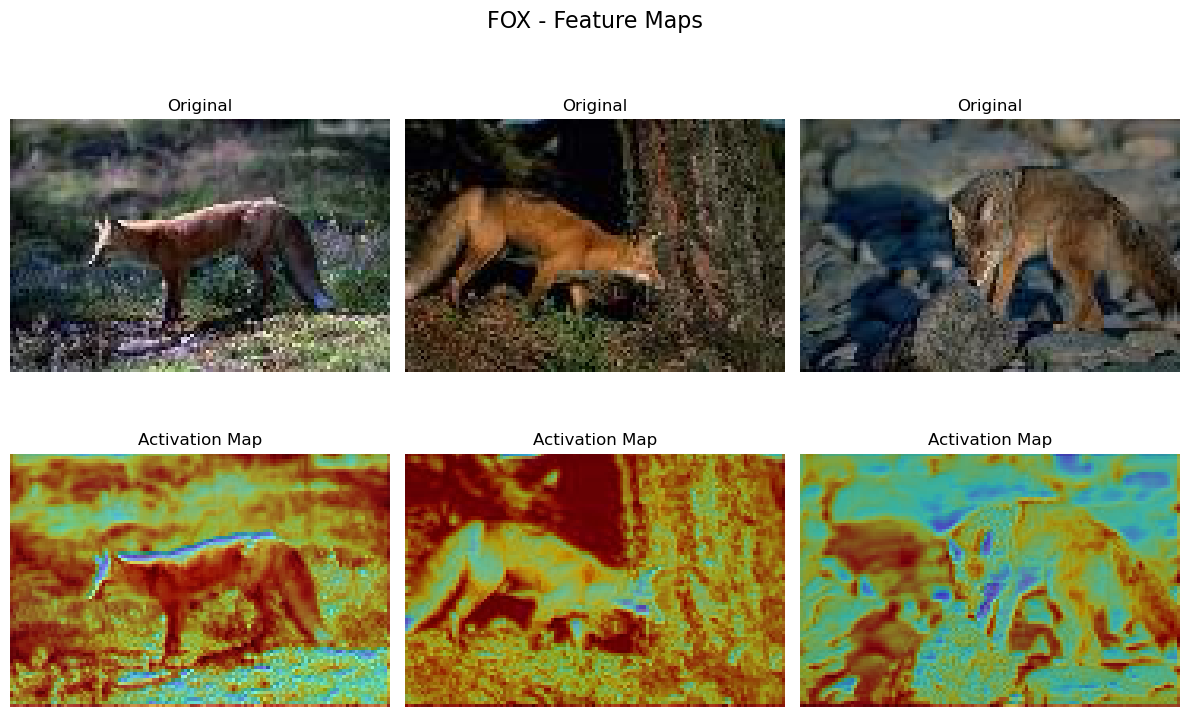

In [43]:
import torch.nn.functional as F

def get_activation_map(model, img_tensor):
    model.eval()
    activation = {}
    def hook_fn(m, i, o):
        activation['conv1'] = o
    hook = model.conv1.register_forward_hook(hook_fn)
    with torch.no_grad():
        _ = model(img_tensor.unsqueeze(0).to(device))
    hook.remove()
    return activation['conv1'].squeeze().cpu()

for animal in animals:
    pos_dir = os.path.join(DATA_ROOT, animal)
    pos_imgs = [os.path.join(pos_dir, f) for f in os.listdir(pos_dir) if f.endswith('.jpg')][:3]
    
    model = CNN_model(img_size=IMG_SIZE).to(device)
    checkpoint = torch.load(f'checkpoints/{animal}_exp.pth', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    fig.suptitle(f'{animal.upper()} - Feature Maps', fontsize=16)
    
    for i, img_path in enumerate(pos_imgs):
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
        img_tensor = torch.from_numpy(img_resized.astype(np.float32) / 255.0).permute(2, 0, 1)
        
        axes[0, i].imshow(img_rgb)
        axes[0, i].axis('off')
        axes[0, i].set_title('Original')
        
        activation_map = get_activation_map(model, img_tensor)
        feature_map = activation_map.mean(0).numpy()
        feature_map = cv2.resize(feature_map, (img_rgb.shape[1], img_rgb.shape[0]))
        
        axes[1, i].imshow(img_rgb)
        axes[1, i].imshow(feature_map, cmap='jet', alpha=0.5)
        axes[1, i].axis('off')
        axes[1, i].set_title('Activation Map')
    
    plt.tight_layout()
    plt.show()

#### Train the module with transfer learning

In [52]:
def train_transfer(model, train_loader, val_loader, epochs, animal, checkpoint_dir='checkpoints'):
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    # Print class distribution
    train_dataset = train_loader.dataset.dataset  # Get original dataset from Subset
    pos_count = sum(train_dataset.labels)
    neg_count = len(train_dataset.labels) - pos_count
    print(f"Training with: {int(pos_count)} positive, {int(neg_count)} negative images")
    
    # WEIGHTED LOSS: pos_weight=1/3 because we have 3x more positive (300) than negative (100)
    pos_weight = torch.tensor([1/3]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    # REDUCED LR and INCREASED weight_decay to reduce overfitting
    optimizer = optim.AdamW(model.parameters(), lr=0.00001, weight_decay=0.1)
    # Scale LR into half if 10 epochs the metric doesn't improve
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    train_losses = []
    val_losses = []
    patience_counter = 0
    early_stop_patience = 15
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        # loop over images by batch
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).unsqueeze(1)  # reshape labels to [batch,1] from [batch]
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                # change the shape of label tensor from [batch] to [batch,1]
                images, labels = images.to(device), labels.to(device).unsqueeze(1)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
        #  the average loss over all batches in the epoch
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        accuracy = 100 * correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        if (epoch + 1) % 10 == 0:  # Print loss only each 10 epochs
            print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Accuracy: {accuracy:.2f}%")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"Early stop at epoch {epoch+1}")
                break 

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'accuracy': accuracy
    }

    torch.save(checkpoint, os.path.join(checkpoint_dir, f'{animal}_transfer.pth'))

    return train_losses, val_losses









 Training ELEPHANT Binary Classification


/info/etu/m2/s2405959/miniconda3/envs/deeplearning/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/info/etu/m2/s2405959/miniconda3/envs/deeplearning/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training with: 300 positive, 100 negative images
Epoch [10/80] Train Loss: 0.3039 | Val Loss: 0.2899 | Accuracy: 88.75%
Epoch [20/80] Train Loss: 0.2497 | Val Loss: 0.2385 | Accuracy: 91.25%
Epoch [30/80] Train Loss: 0.1958 | Val Loss: 0.1966 | Accuracy: 95.00%
Epoch [40/80] Train Loss: 0.1699 | Val Loss: 0.1687 | Accuracy: 95.00%
Epoch [50/80] Train Loss: 0.1653 | Val Loss: 0.1458 | Accuracy: 96.25%
Epoch [60/80] Train Loss: 0.1378 | Val Loss: 0.1346 | Accuracy: 92.50%
Epoch [70/80] Train Loss: 0.1218 | Val Loss: 0.1238 | Accuracy: 96.25%
Epoch [80/80] Train Loss: 0.1114 | Val Loss: 0.1114 | Accuracy: 92.50%


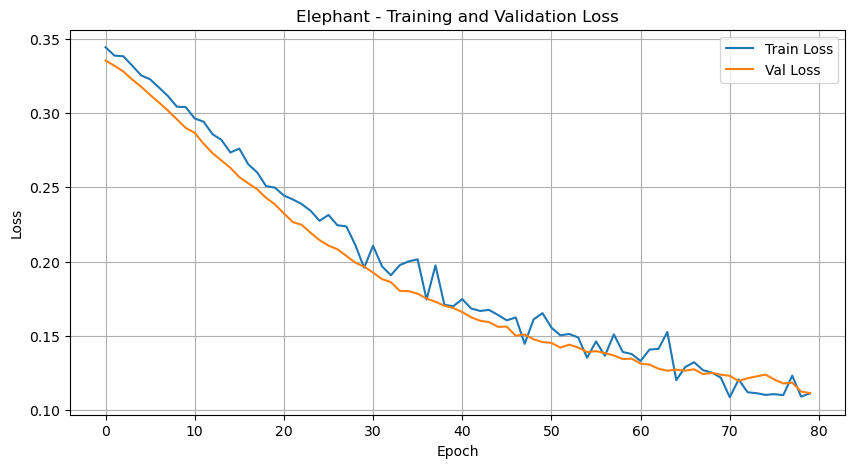


 Training TIGER Binary Classification


/info/etu/m2/s2405959/miniconda3/envs/deeplearning/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/info/etu/m2/s2405959/miniconda3/envs/deeplearning/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training with: 300 positive, 100 negative images
Epoch [10/80] Train Loss: 0.2934 | Val Loss: 0.2899 | Accuracy: 92.50%
Epoch [20/80] Train Loss: 0.2427 | Val Loss: 0.2308 | Accuracy: 96.25%
Epoch [30/80] Train Loss: 0.1910 | Val Loss: 0.1830 | Accuracy: 95.00%
Epoch [40/80] Train Loss: 0.1616 | Val Loss: 0.1500 | Accuracy: 96.25%
Epoch [50/80] Train Loss: 0.1390 | Val Loss: 0.1279 | Accuracy: 96.25%
Epoch [60/80] Train Loss: 0.1132 | Val Loss: 0.1138 | Accuracy: 95.00%
Epoch [70/80] Train Loss: 0.1063 | Val Loss: 0.1026 | Accuracy: 95.00%
Epoch [80/80] Train Loss: 0.0912 | Val Loss: 0.0934 | Accuracy: 95.00%


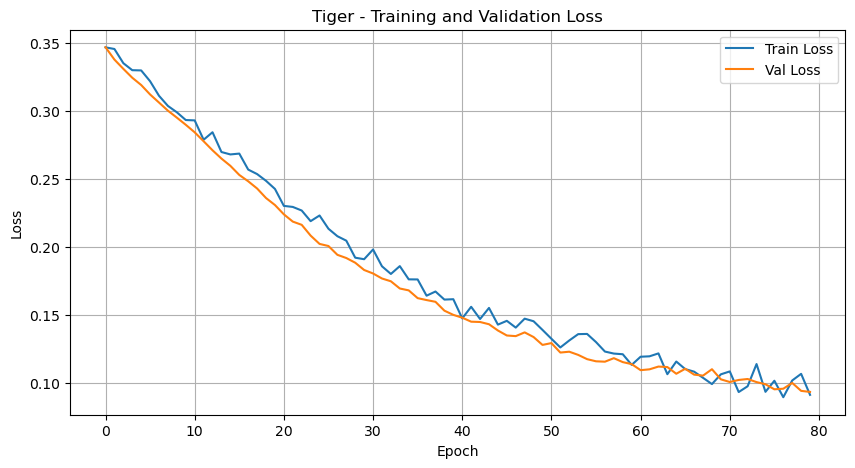


 Training FOX Binary Classification


/info/etu/m2/s2405959/miniconda3/envs/deeplearning/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/info/etu/m2/s2405959/miniconda3/envs/deeplearning/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training with: 300 positive, 100 negative images
Epoch [10/80] Train Loss: 0.3014 | Val Loss: 0.2922 | Accuracy: 55.00%
Epoch [20/80] Train Loss: 0.2472 | Val Loss: 0.2265 | Accuracy: 86.25%
Epoch [30/80] Train Loss: 0.1906 | Val Loss: 0.1770 | Accuracy: 93.75%
Epoch [40/80] Train Loss: 0.1586 | Val Loss: 0.1404 | Accuracy: 97.50%
Epoch [50/80] Train Loss: 0.1487 | Val Loss: 0.1162 | Accuracy: 97.50%
Epoch [60/80] Train Loss: 0.1207 | Val Loss: 0.1007 | Accuracy: 97.50%
Epoch [70/80] Train Loss: 0.1100 | Val Loss: 0.0876 | Accuracy: 98.75%
Epoch [80/80] Train Loss: 0.0888 | Val Loss: 0.0794 | Accuracy: 98.75%


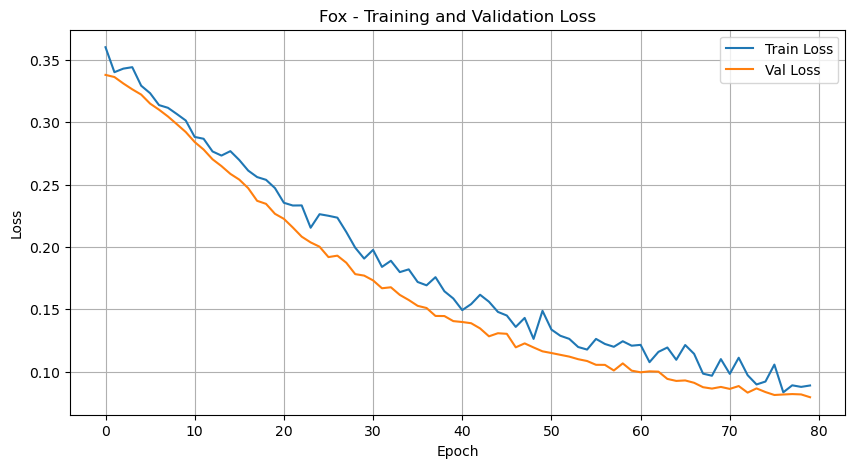

In [53]:
BATCH_SIZE = 16
EPOCHS = 80
IMG_SIZE = 128

animals = ['elephant', 'tiger', 'fox']
results = {}

for animal in animals:
    print(f"\n Training {animal.upper()} Binary Classification")

    train_dataset = AnimalBinaryDataset(DATA_ROOT,animal, img_size=(IMG_SIZE,IMG_SIZE))
    val_dataset = AnimalBinaryDataset(DATA_ROOT,animal, img_size=(IMG_SIZE,IMG_SIZE))

    train_idx, val_idx = train_test_split(range(len(train_dataset)), test_size=0.2, random_state=42, stratify=train_dataset.labels)

    train_subset = torch.utils.data.Subset(train_dataset, train_idx)
    val_subset =  torch.utils.data.Subset(val_dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=True)

    model = CNN_model_ResNet50().to(device)
    train_losses, val_losses = train_transfer(model, train_loader, val_loader, EPOCHS, animal)

    results[animal] = {'train_losses': train_losses,'val_losses': val_losses}

    plot_losses(train_losses, val_losses, animal)

### Test models with images from the internet. 

In [61]:
test_dir = '/info/etu/m2/s2405959/deepLearning/L3_project/test_samples'
test_images = sorted([f for f in os.listdir(test_dir) if f.endswith('.jpg')])

for img_name in test_images:
    # Get true animal from filename (handle typos)
    true_animal = None
    if 'elephant' in img_name.lower() or 'elephen' in img_name.lower():
        true_animal = 'elephant'
    elif 'fox' in img_name.lower() or 'for' in img_name.lower():
        true_animal = 'fox'
    elif 'tiger' in img_name.lower():
        true_animal = 'tiger'
    
    # Load and process image
    img_path = os.path.join(test_dir, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = torch.from_numpy(cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device)
    
    # Test with the correct model
    if true_animal:
        model = CNN_model_ResNet50().to(device)
        ckpt = torch.load(f'checkpoints/{true_animal}_transfer.pth', map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        model.eval()
        
        with torch.no_grad():
            prob = torch.sigmoid(model(img_tensor)).item()
        
        prediction = "YES" if prob > 0.5 else "NO"
        print(f"{img_name:25} | Prediction: {prediction} - {true_animal.upper()} ({prob:.2%})")

elephen_real.jpg          | Prediction: YES - ELEPHANT (93.56%)
elephent_fake.jpg         | Prediction: NO - ELEPHANT (28.44%)
elephent_fake.jpg         | Prediction: NO - ELEPHANT (28.44%)
fox_fake.jpg              | Prediction: NO - FOX (16.23%)
fox_fake.jpg              | Prediction: NO - FOX (16.23%)
fox_real.jpg              | Prediction: YES - FOX (70.01%)
fox_real.jpg              | Prediction: YES - FOX (70.01%)
tiger_fake.jpg            | Prediction: NO - TIGER (31.15%)
tiger_fake.jpg            | Prediction: NO - TIGER (31.15%)
tiger_real.jpg            | Prediction: YES - TIGER (96.83%)
tiger_real.jpg            | Prediction: YES - TIGER (96.83%)
